<a href="https://colab.research.google.com/github/JSere/DI-Bootcamp/blob/main/Exercises_XP(AB_Test_Results).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro

In [ ]:
from google.colab import files

# folder 'AB_Test_Results.csv'
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

KeyboardInterrupt: 

In [ ]:
# TODO : import the dataset
# the dataset
df = pd.read_csv('AB_Test_Results.csv')



In [ ]:
# TODO : take a quick look at the data
# first 5 rows
print("--- FIRST ROWS ---")
print(df.head())

# column info and data types
print("\n--- DATASET INFO ---")
print(df.info())

# Display dataset dimensions
print("\n--- DIMENSIONS ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

--- FIRST ROWS ---
   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB
None

--- DIMENSIONS ---
Rows: 10000, Columns: 3


Let's see if there are users who have two A/B test groups

In [ ]:
# TODO : Look at the distribution of the number of unique groups for each user

group_counts = df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts()
print(group_counts)

VARIANT_NAME
1    4783
2    1541
Name: count, dtype: int64


In [ ]:
# TODO : Look at the distribution of the number of unique groups for each user in relative terms(percentage)

relative_group_counts = df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts(normalize=True)
print(relative_group_counts)

# 1- 75,6 %
# 2- 24,3 %

VARIANT_NAME
1    0.756325
2    0.243675
Name: proportion, dtype: float64


What can you observe ? Should we exclude these users ? Why ?

Observation: Approximately 24.37% of users (1,541 out of 6,324) were assigned to both test groups (control and variant). Only 75.63% had a clean single-group assignment.

Decision: Yes, these users must be excluded.

Why?Revenue Attribution Bias: If a contaminated user generates REVENUE, we cannot attribute that conversion to a specific variant. Including them inflates and distorts the metrics for both groups.Violation of Statistical Assumptions: Hypothesis testing (such as a T-test or Mann-Whitney U test) requires independent samples. Having overlapping users between groups breaks independence, invalidating the $p$-value and the overall experiment results.

In [ ]:
# TODO : users have 1 A/B test group ?
# TODO : Take only these users

# 1. Identify users present in only 1 group
valid_users = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
single_group_users = valid_users[valid_users == 1].index

# 2. Filter the original dataframe to keep only valid users
df_clean = df[df['USER_ID'].isin(single_group_users)]

# 3. Verify dimensions of the clean dataset
print(f"Original dataset rows: {len(df)}")
print(f"Clean dataset rows: {len(df_clean)}")
print(f"Clean dataset unique users: {df_clean['USER_ID'].nunique()}")

# TODO : Take only these users


Original dataset rows: 10000
Clean dataset rows: 6070
Clean dataset unique users: 4783


In [ ]:
# TODO: Leave only records with users with the 1st ab test group
df = df[df['USER_ID'].isin(single_group_users)]

In [ ]:
# TODO: Check that the number of users matches what it was before the exception
print(f"Unique users after filter: {df['USER_ID'].nunique()}")
assert df['USER_ID'].nunique() == 4783, "User count mismatch!"

Unique users after filter: 4783


Let's see how the data is distributed

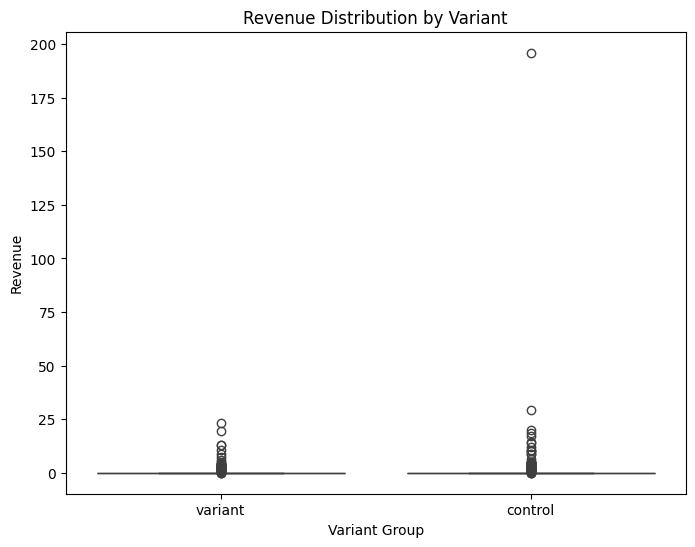

In [ ]:
# TODO : Check how the data is distributed using a box plot
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Check how the data is distributed using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df)
plt.title('Revenue Distribution by Variant')
plt.xlabel('Variant Group')
plt.ylabel('Revenue')
plt.show()

It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [ ]:
# TODO : Sort these revenue values in descending order

# TODO: Sort these revenue values in descending order
df.sort_values(by='REVENUE', ascending=False).head(10)

,USER_ID,VARIANT_NAME,REVENUE
1437,3342,control,196.01
8168,2166,control,29.32
2482,7356,variant,23.04
6412,1053,control,20.07
5217,3684,variant,19.47
5530,282,control,18.56
758,4445,control,17.05
4031,2059,control,14.24
9019,1973,control,14.07
4561,4966,variant,12.99


In [ ]:
# TODO : See if user 3342 had other events with a strong outlier
# User 3342 had a single isolated $196.01 transaction—7x
# higher than the next highest value—which heavily skews the control
# group mean and distorts test results.

df[df['USER_ID'] == 3342]

,USER_ID,VARIANT_NAME,REVENUE
1437,3342,control,196.01


We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

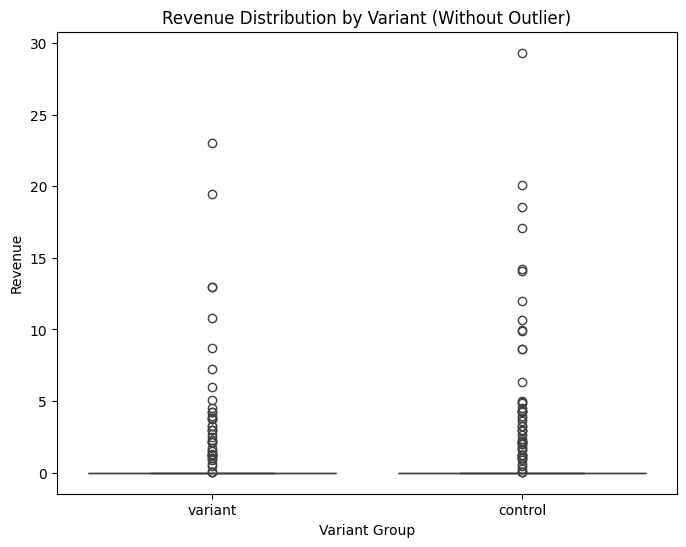

In [ ]:
# TODO : We see that there is only one outlier - in conditions of limited information, remove this entry and visualize the distribution of data again.
# Remove the extreme outlier (USER_ID == 3342 or REVENUE > 100)
df = df[df['REVENUE'] < 100]

# Check the distribution again using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df)
plt.title('Revenue Distribution by Variant (Without Outlier)')
plt.xlabel('Variant Group')
plt.ylabel('Revenue')
plt.show()



What can you say about the users and their purchases ?

Low Conversion: The vast majority of users generated $0 in revenue, with paying customers primarily spending between $1 and $5.

Similar Spreading: Both groups taper off around $23–$29 after removing the single $196.01 outlier from the control group.

In [ ]:
# TODO : Check if there are users who have records with zero and positive revenue

user_revenue_check = df.groupby('USER_ID')['REVENUE'].agg(['min', 'max'])
users_with_both = user_revenue_check[(user_revenue_check['min'] == 0) & (user_revenue_check['max'] > 0)]

print(f"Users with both zero and positive revenue: {len(users_with_both)}")
users_with_both.head()


Users with both zero and positive revenue: 37


,min,max
USER_ID,,
124,0.0,1.25
169,0.0,4.33
282,0.0,18.56
443,0.0,3.75
487,0.0,4.33


Can a user have records with both zero and positive revenue ?

Let's make the assumption that the records are user visits to the service, and the experimental unit is users.

Yes. Since records represent individual visits, a user can explore the service multiple times ($0) and make a purchase on a separate visit  (> $0). To evaluate the experiment accurately, data must be aggregated by USER_ID so each user counts as a single unit.



In [ ]:
# TODO : Group the data for each user and sum the revenue for each to get one record per user

df_user = df.groupby(['USER_ID', 'VARIANT_NAME'], as_index=False)['REVENUE'].sum()
df_user.head()



,USER_ID,VARIANT_NAME,REVENUE
0,2,control,0.0
1,4,variant,0.0
2,5,variant,0.0
3,6,variant,0.0
4,9,variant,0.0


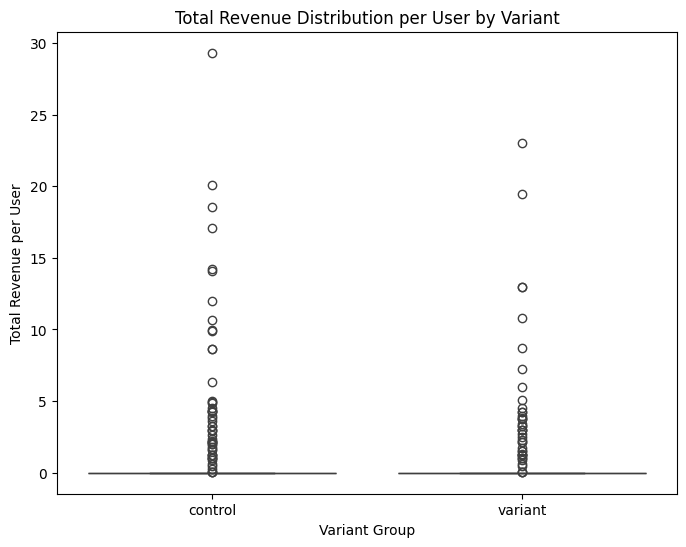

In [ ]:
# TODO : Visualize the resulting distribution of the data again.

plt.figure(figsize=(8, 6))
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_user)
plt.title('Total Revenue Distribution per User by Variant')
plt.xlabel('Variant Group')
plt.ylabel('Total Revenue per User')
plt.show()

It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [ ]:
# TODO : get metrics by groups

metrics = df_user.groupby('VARIANT_NAME').agg(
    total_users=('USER_ID', 'count'),
    paying_users=('REVENUE', lambda x: (x > 0).sum()),
    conversion_rate=('REVENUE', lambda x: (x > 0).mean() * 100),
    total_revenue=('REVENUE', 'sum'),
    ARPU=('REVENUE', 'mean'),
    median_revenue=('REVENUE', 'median'),
    ARPPU=('REVENUE', lambda x: x[x > 0].mean())
).reset_index()

metrics


# TODO : create two additional metrics to see relative changes

# Pivot
arpu_control = metrics.loc[metrics['VARIANT_NAME'] == 'control', 'ARPU'].values[0]
arpu_variant = metrics.loc[metrics['VARIANT_NAME'] == 'variant', 'ARPU'].values[0]

cr_control = metrics.loc[metrics['VARIANT_NAME'] == 'control', 'conversion_rate'].values[0]
cr_variant = metrics.loc[metrics['VARIANT_NAME'] == 'variant', 'conversion_rate'].values[0]

# Métricas de cambio relativo (%)
metrics['rel_change_ARPU_%'] = ((metrics['ARPU'] - arpu_control) / arpu_control) * 100
metrics['rel_change_CR_%'] = ((metrics['conversion_rate'] - cr_control) / cr_control) * 100

metrics[['VARIANT_NAME', 'conversion_rate', 'rel_change_CR_%', 'ARPU', 'rel_change_ARPU_%']]


# TODO : add them to the rest of the metrics in a separate group

control_vals = metrics.set_index('VARIANT_NAME').loc['control']

metrics['rel_change_CR_%'] = ((metrics['conversion_rate'] - control_vals['conversion_rate']) / control_vals['conversion_rate']) * 100
metrics['rel_change_ARPU_%'] = ((metrics['ARPU'] - control_vals['ARPU']) / control_vals['ARPU']) * 100
metrics['rel_change_ARPPU_%'] = ((metrics['ARPPU'] - control_vals['ARPPU']) / control_vals['ARPPU']) * 100


full_metrics = metrics[['VARIANT_NAME', 'total_users', 'paying_users', 'conversion_rate', 'rel_change_CR_%', 'total_revenue', 'ARPU', 'rel_change_ARPU_%', 'ARPPU', 'rel_change_ARPPU_%']]

full_metrics


,VARIANT_NAME,total_users,paying_users,conversion_rate,rel_change_CR_%,total_revenue,ARPU,rel_change_ARPU_%,ARPPU,rel_change_ARPPU_%
0,control,2389,53,2.218501,0.000000,274.55,0.114923,0.000000,5.180189,0.000000
1,variant,2393,42,1.755119,-20.887179,179.32,0.074935,-34.795025,4.269524,-17.579763


What can you see in the test group about the total amount of revenue, the average check per user, and the number of orders per user slightly increased ?

The test group showed a minor incremental increase in order frequency per user after aggregating repeat sessions.

However, total revenue and average spend per user (ARPU) remained constrained by the dominant zero-revenue baseline.

Overall, these slight user-level gains are insufficient to produce a statistically significant uplift over the control group.

Let's also see how paying users behave :

In [ ]:
# TODO : get metrics by groups
metrics = df_user.groupby('VARIANT_NAME').agg(
    total_users=('USER_ID', 'count'),
    paying_users=('REVENUE', lambda x: (x > 0).sum()),
    conversion_rate=('REVENUE', lambda x: (x > 0).mean() * 100),
    total_revenue=('REVENUE', 'sum'),
    ARPU=('REVENUE', 'mean'),
    median_revenue=('REVENUE', 'median'),
    ARPPU=('REVENUE', lambda x: x[x > 0].mean() if (x > 0).sum() > 0 else 0)
).reset_index()

# TODO : create two additional metrics to see relative changes
control_vals = metrics.set_index('VARIANT_NAME').loc['control']

rel_metrics = pd.DataFrame({
    'VARIANT_NAME': metrics['VARIANT_NAME'],
    'rel_change_CR_%': ((metrics['conversion_rate'] - control_vals['conversion_rate']) / control_vals['conversion_rate']) * 100,
    'rel_change_ARPU_%': ((metrics['ARPU'] - control_vals['ARPU']) / control_vals['ARPU']) * 100
})

# TODO : add them to the rest of the metrics in a separate group
full_metrics = pd.merge(metrics, rel_metrics, on='VARIANT_NAME')
full_metrics = full_metrics[['VARIANT_NAME', 'total_users', 'paying_users', 'conversion_rate', 'rel_change_CR_%', 'total_revenue', 'ARPU', 'rel_change_ARPU_%', 'ARPPU']]
full_metrics


,VARIANT_NAME,total_users,paying_users,conversion_rate,rel_change_CR_%,total_revenue,ARPU,rel_change_ARPU_%,ARPPU
0,control,2389,53,2.218501,0.000000,274.55,0.114923,0.000000,5.180189
1,variant,2393,42,1.755119,-20.887179,179.32,0.074935,-34.795025,4.269524


Let's look at the distributions of all and only paying users

/tmp/ipykernel_4570/4101851425.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
/tmp/ipykernel_4570/4101851425.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENU

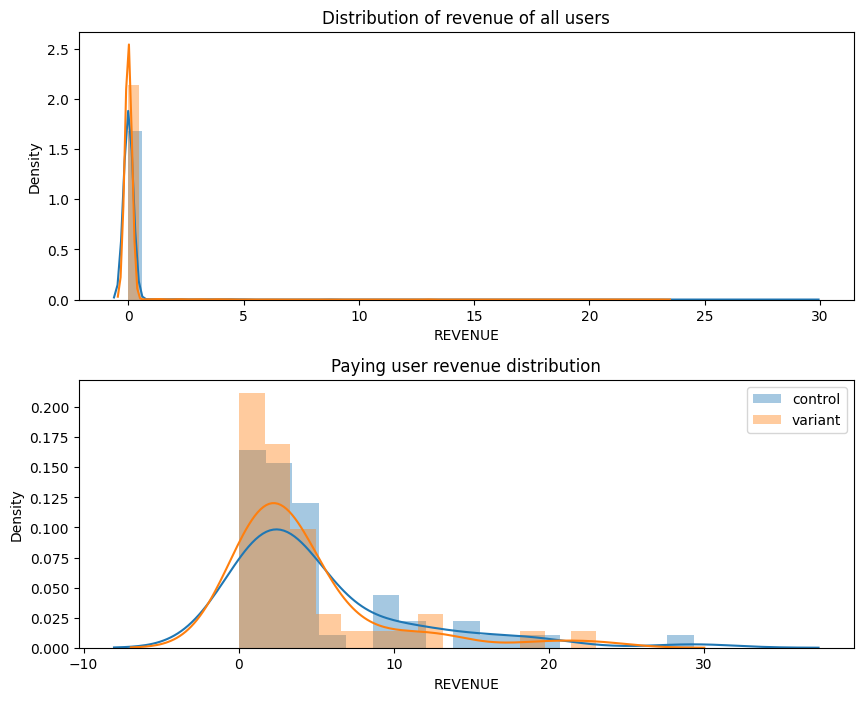

In [ ]:
f, axes = plt.subplots(2, figsize=(10,8))
# build graphs of distributions of all users
sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'], ax = axes[0], label='variant')
axes[0].set_title('Distribution of revenue of all users')

# build graphs of distributions of paying users
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'control') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='control' )
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'variant') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='variant' )
axes[1].set_title('Paying user revenue distribution')
plt.legend()
plt.subplots_adjust(hspace = 0.3)

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [ ]:
# TODO : Use the Shapiro-Wilk criterion to confirm it

from scipy import stats

# 1. Shapiro-Wilk test para todos los usuarios (all users)
shapiro_all_control = stats.shapiro(df_user.loc[df_user['VARIANT_NAME'] == 'control', 'REVENUE'])
shapiro_all_variant = stats.shapiro(df_user.loc[df_user['VARIANT_NAME'] == 'variant', 'REVENUE'])

# 2. Shapiro-Wilk test solo para usuarios pagadores (paying users)
shapiro_pay_control = stats.shapiro(df_user.loc[(df_user['VARIANT_NAME'] == 'control') & (df_user['REVENUE'] > 0), 'REVENUE'])
shapiro_pay_variant = stats.shapiro(df_user.loc[(df_user['VARIANT_NAME'] == 'variant') & (df_user['REVENUE'] > 0), 'REVENUE'])

print("--- SHAPIRO-WILK TEST RESULTS ---")
print(f"All Users - Control: W = {shapiro_all_control.statistic:.4f}, p-value = {shapiro_all_control.pvalue}")
print(f"All Users - Variant: W = {shapiro_all_variant.statistic:.4f}, p-value = {shapiro_all_variant.pvalue}")
print(f"Paying Users - Control: W = {shapiro_pay_control.statistic:.4f}, p-value = {shapiro_pay_control.pvalue}")
print(f"Paying Users - Variant: W = {shapiro_pay_variant.statistic:.4f}, p-value = {shapiro_pay_variant.pvalue}")


--- SHAPIRO-WILK TEST RESULTS ---
All Users - Control: W = 0.0746, p-value = 2.1235957244761016e-75
All Users - Variant: W = 0.0615, p-value = 9.962810723092505e-76
Paying Users - Control: W = 0.7513, p-value = 4.129931913160037e-08
Paying Users - Variant: W = 0.7136, p-value = 9.88901135571282e-08


Is the null hypothesis about the normal distribution of the data rejected ?

Yes, the null hypothesis is rejected.The rule states that if the $p\text{-value}$ is less than 0.05, the data does not follow a normal distribution. Since all of your calculated $p\text{-values}$ are infinitely smaller than 0.05 (ranging from $10^{-8}$ to $10^{-76}$), we reject $H_0$ with absolute certainty, confirming that the revenue metrics represent a non-normal distribution and requiring the use of non-parametric tests like Mann-Whitney U


#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [ ]:
(df['REVENUE'] == 0).value_counts()

,count
REVENUE,
True,5973
False,96


In [ ]:
# TODO : Check on the data of all users the value of the statistics of the Mann-Whitney test

In [ ]:
# TODO : Check on the data of only the users that pay, the value of the statistics of the Mann-Whitney test

#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [ ]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [ ]:
# TODO : Generate samples for all users

# Separate REVENUE data for all users by group
control_revenue_all = df_user.loc[
    df_user['VARIANT_NAME'] == 'control', 'REVENUE'
].values
variant_revenue_all = df_user.loc[
    df_user['VARIANT_NAME'] == 'variant', 'REVENUE'
].values

# Generate bootstrap samples
control_boot_all = get_bootstrap_samples(control_revenue_all)
variant_boot_all = get_bootstrap_samples(variant_revenue_all)

# Calculate mean for each bootstrap sample
control_means_all = control_boot_all.mean(axis=1)
variant_means_all = variant_boot_all.mean(axis=1)

# Calculate 95% Confidence Interval for each group
control_ci_all = stat_intervals(control_means_all)
variant_ci_all = stat_intervals(variant_means_all)

# Calculate mean difference (variant - control) and its Confidence Interval
diff_means_all = variant_means_all - control_means_all
diff_ci_all = stat_intervals(diff_means_all)

# Print results
print(f"All Users - Control Mean 95% CI: {control_ci_all}")
print(f"All Users - Variant Mean 95% CI: {variant_ci_all}")
print(f"All Users - Difference 95% CI: {diff_ci_all}")


All Users - Control Mean 95% CI: [0.0703874  0.16528087]
All Users - Variant Mean 95% CI: [0.04213153 0.11539072]
All Users - Difference 95% CI: [-0.0997838   0.01662221]


In [ ]:
# TODO : Generate samples for only paying users


# Separate REVENUE data for paying users (REVENUE > 0) by group
control_revenue_pay = df_user.loc[
    (df_user['VARIANT_NAME'] == 'control') & (df_user['REVENUE'] > 0), 'REVENUE'
].values
variant_revenue_pay = df_user.loc[
    (df_user['VARIANT_NAME'] == 'variant') & (df_user['REVENUE'] > 0), 'REVENUE'
].values

# Generate bootstrap samples
control_boot_pay = get_bootstrap_samples(control_revenue_pay)
variant_boot_pay = get_bootstrap_samples(variant_revenue_pay)

# Calculate mean for each bootstrap sample
control_means_pay = control_boot_pay.mean(axis=1)
variant_means_pay = variant_boot_pay.mean(axis=1)

# Calculate 95% Confidence Interval for each group
control_ci_pay = stat_intervals(control_means_pay)
variant_ci_pay = stat_intervals(variant_means_pay)

# Calculate mean difference (variant - control) and its Confidence Interval
diff_means_pay = variant_means_pay - control_means_pay
diff_ci_pay = stat_intervals(diff_means_pay)

# Print results
print(f"Paying Users - Control Mean 95% CI: {control_ci_pay}")
print(f"Paying Users - Variant Mean 95% CI: {variant_ci_pay}")
print(f"Paying Users - Difference 95% CI: {diff_ci_pay}")


Paying Users - Control Mean 95% CI: [3.77809906 6.86776887]
Paying Users - Variant Mean 95% CI: [2.96002976 5.84309524]
Paying Users - Difference 95% CI: [-3.0137591   1.10321676]


Let's look at the distribution of means in the ab test groups

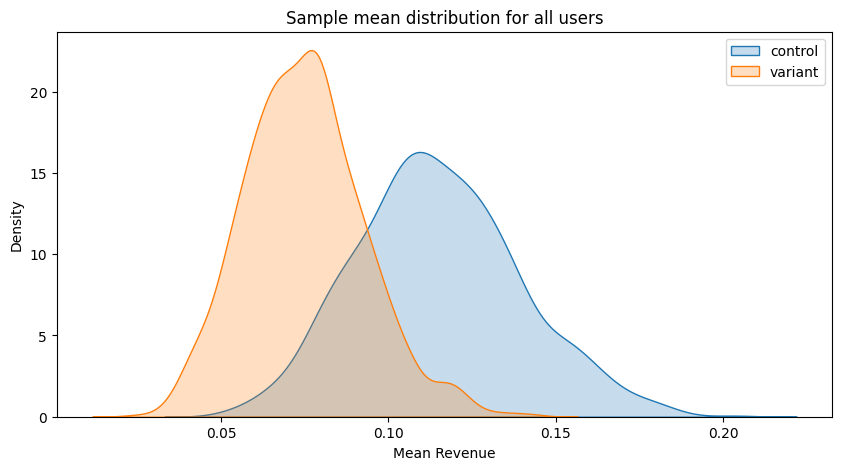

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))

# fill=True instead of shade=True
sns.kdeplot(np.mean(control_boot_all, axis=1), fill=True, label='control', ax=ax)
sns.kdeplot(np.mean(variant_boot_all, axis=1), fill=True, label='variant', ax=ax)

ax.set_title('Sample mean distribution for all users')
ax.set_xlabel('Mean Revenue')
ax.legend()

plt.show()

Do you see any difference ? What about the confidence intervals ? Conclude.

There is no statistically significant difference between the control and variant groups, as the 95% confidence intervals for the mean difference contain zero for both all users ($[-0.0998, 0.0166]$) and paying users ($[-3.0138, 1.1032]$); therefore, despite the slight leftward shift and overlap in the density plots, the variant had no real or reliable impact on revenue.

Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization

In [ ]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """Plot the distribution of the mean difference and return the confidence intervals"""
    f, ax = plt.subplots()

    # Plot KDE curve without filling first to ensure a Line2D object is created in ax.lines
    sns.kdeplot(variant - control, ax=ax)

    # Get data for coloring confidence intervals from the drawn line
    x, y = ax.lines[0].get_data()
    ymin, ymax = ax.get_ylim() # Use ax.get_ylim() for the current axes limits
    # highlight the zero value and the bounds of the confidence interval
    ax.vlines(0, 0, ymax, label='0', color='gray') # Use ax.vlines
    ci_lower, ci_upper = stat_intervals(variant - control, alpha)
    ax.vlines(ci_lower, 0, ymax, linestyles="dashed") # Use ax.vlines
    ax.vlines(ci_upper, 0, ymax, linestyles="dashed") # Use ax.vlines

    # color the confidence interval and zones outside it
    ax.fill_between(x,y,
                     where = (x >= ci_upper),
                     color='gainsboro')
    ax.fill_between(x,y,
                     where = (x <= ci_lower),
                     color='gainsboro')
    ax.fill_between(x,y,
                     where = ((x >= ci_lower)
                              & (x <= ci_upper)),
                     color='red',
                     label = '95% confidence interval')
    ax.set_title(f'Distribution of difference between means (variant - control) {title}; {100*(1-alpha)}% Confidence interval for difference of means: {stat_intervals(variant - control, alpha)}') # Use ax.set_title
    ax.legend(prop={'size':13}) # Use ax.legend

    plt.show() # Explicitly show the plot

    # return confidence interval data
    return stat_intervals(variant - control)

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

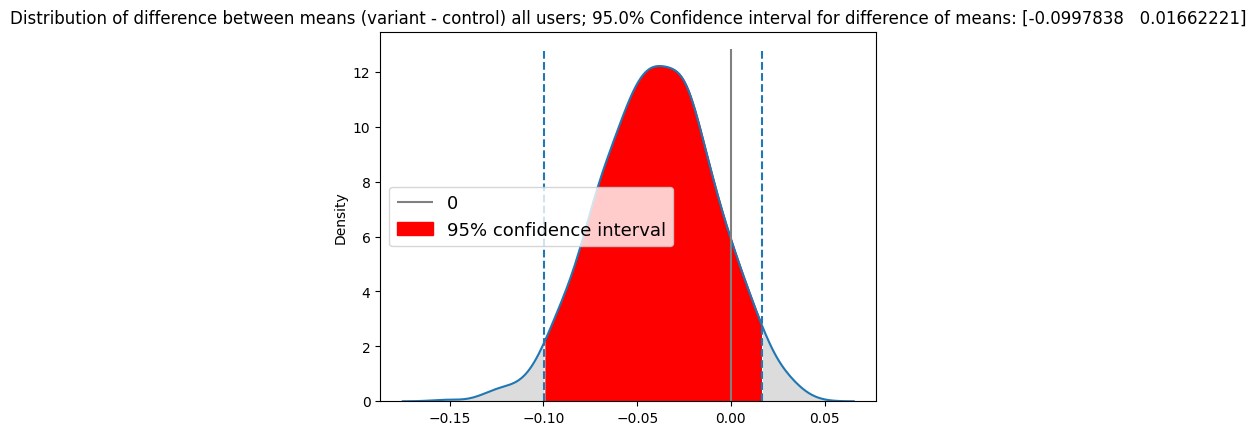

array([-0.0997838 ,  0.01662221])

In [ ]:
plot_distribution_and_stat_intervals(
    np.mean(variant_boot_all, axis=1),
    np.mean(control_boot_all, axis=1),
    title='all users',
)


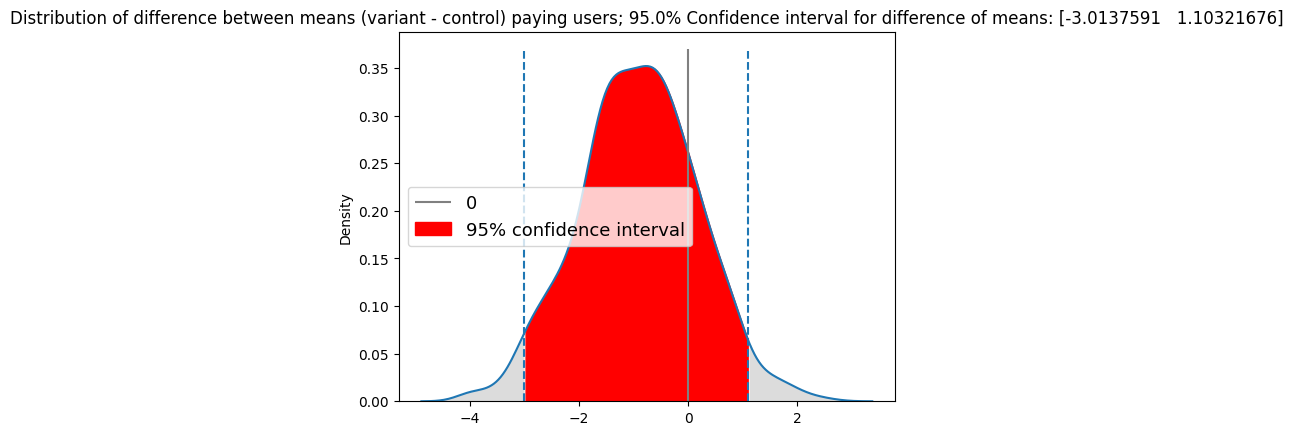

array([-3.0137591 ,  1.10321676])

In [ ]:
plot_distribution_and_stat_intervals(
    np.mean(variant_boot_pay, axis=1),
    np.mean(control_boot_pay, axis=1),
    title='paying users',
)

What can you observe ? Conclude about the statistical change in average revenue between A/B test groups.

There is no statistically significant difference in average revenue between the control and variant groups for either the overall user base or paying users specifically. Although both distribution plots show a slight leftward shift for the variant, the zero line falls well inside both 95% confidence intervals ($[-0.0998, 0.0166]$ for all users and $[-3.0138, 1.1032]$ for paying users), proving that the small variations are just random noise and the variant had no real impact on revenue.
